# Laboratorio 5 - Naive Bayes

Este notebook cubre los primeros cinco incisos del laboratorio:

1. Construir un modelo de regresion con Naive Bayes para predecir `price`.
2. Evaluar que tan bien funciona usando metricas correctas de regresion.
3. Comparar Naive Bayes contra regresion lineal y arbol de regresion.
4. Construir un modelo de clasificacion usando la categoria de precio.
5. Utilizar los modelos con el conjunto de prueba y determinar la eficiencia del algoritmo para predecir y clasificar.

## Estructura

1. Imports y configuracion
2. Carga de datos
3. Preparacion de datos
4. Inciso 1 - Modelo de Regresion con Naive Bayes
5. Inciso 2 - Evaluacion del Modelo de Regresion
6. Inciso 3 - Comparacion con Regresion Lineal y Arbol de Regresion
7. Inciso 4 - Modelo de Clasificacion con Categoria de Precio
8. Inciso 5 - Eficiencia del Algoritmo para Predecir y Clasificar

In [113]:
%pip install pyreadr pandas scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


## Imports y Configuracion

In [114]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyreadr
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB, CategoricalNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import KBinsDiscretizer, OneHotEncoder, OrdinalEncoder
from sklearn.tree import DecisionTreeRegressor

DATA_PATH = Path("listings.RData")
RANDOM_STATE = 42
TEST_SIZE = 0.20

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)


## Carga de Datos

Cargamos el archivo `listings.RData` y verificamos el objeto principal.

In [115]:
result = pyreadr.read_r(DATA_PATH)
print("Objetos encontrados en el RData:")
print(list(result.keys()))

df = result["listings"].copy()
print(f"Dimensiones del DataFrame: {df.shape}")
display(df.head())

Objetos encontrados en el RData:
['listings']
Dimensiones del DataFrame: (171748, 80)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,https://www.airbnb.com/users/show/8028,Sylvia,2009-02-16,"Austin, TX",I am a licensed Real Estate Broker and owner o...,within a few hours,100%,90%,t,https://a0.muscache.com/im/users/8028/profile_...,https://a0.muscache.com/im/users/8028/profile_...,East Downtown,1,2,"['email', 'phone']",t,t,Neighborhood highlights,78702,NaN,30.26057,-97.73441,Entire guesthouse,Entire home/apt,3,1.0,1 bath,1,2,"[""Iron"", ""Private entrance"", ""Hot water"", ""Dis...",$97.00,2,90,2,4,90,90,2.1,90.0,NaN,t,13,35,65,328,2025-09-17,708,25,1,81,33,150,14550,2009-03-19,2025-09-02,4.85,4.88,4.86,4.90,4.82,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,https://www.airbnb.com/users/show/14156,Amy,2009-04-20,"Austin, TX","We are a family of four (with teenagers, all o...",within an hour,100%,96%,t,https://a0.muscache.com/im/users/14156/profile...,https://a0.muscache.com/im/users/14156/profile...,Zilker,1,2,"['email', 'phone']",t,t,Neighborhood highlights,78704,NaN,30.26034,-97.76487,Entire guesthouse,Entire home/apt,2,1.0,1 bath,1,2,"[""Private patio or balcony"", ""Stove"", ""Cleanin...",$160.00,3,365,3,3,1125,1125,3.0,1125.0,NaN,t,12,30,50,316,2025-09-17,339,14,1,61,20,84,13440,2011-09-06,2025-08-20,4.97,4.97,4.96,4.99,4.98,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,https://www.airbnb.com/users/show/25298,Karen,2009-07-11,"Austin, TX",I handle the reservations at the studio on the...,within a day,100%,60%,f,https://a0.muscache.com/im/users/25298/profile...,https://a0.muscache.com/im/users/25298/profile...,East Riverside,1,1,"['email', 'phone']",t,f,,78741,NaN,30.23466,-97.73682,Entire guest suite,Entire home/apt,2,1.0,1 bath,1,1,"[""Wifi"", ""Smoke alarm"", ""Shampoo"", ""Heating"", ...",$38.00,4,90,3,14,90,90,6.0,90.0,NaN,t,29,59,88,88,2025-09-17,54,1,0,88,2,8,304,2010-02-19,2025-05-05,4.57,4.55,4.6

## Preparacion de Datos

Trabajaremos con una base comun para todos los modelos de Naive Bayes.

La idea es mantener condiciones comparables y evitar fuga de informacion:

- limpiamos `price`,
- reutilizamos el criterio de depuracion del laboratorio anterior para variables mixtas,
- excluimos la copia numerica del objetivo (`price_num`) y variables con posible fuga,
- y usamos el mismo `train/test split` para regresion y clasificacion.


In [116]:
def clean_price(series: pd.Series) -> pd.Series:
    cleaned = (
        series.astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    cleaned = cleaned.replace({"nan": np.nan, "None": np.nan, "": np.nan})
    return pd.to_numeric(cleaned, errors="coerce")


def build_modeling_dataset(df: pd.DataFrame):
    df_model = df.copy()
    df_model["price_num"] = clean_price(df_model["price"])
    df_model = df_model.dropna(subset=["price_num"]).copy()

    cols_drop = [
        "id",
        "listing_url",
        "scrape_id",
        "last_scraped",
        "source",
        "name",
        "description",
        "neighborhood_overview",
        "picture_url",
        "host_url",
        "host_name",
        "host_since",
        "host_location",
        "host_about",
        "host_thumbnail_url",
        "host_picture_url",
        "host_verifications",
        "neighbourhood",
        "calendar_updated",
        "calendar_last_scraped",
        "first_review",
        "last_review",
        "license",
        "bathrooms_text",
        "amenities",
        "avail_group",
    ]
    cols_drop = [column for column in cols_drop if column in df_model.columns]
    df_model = df_model.drop(columns=cols_drop).copy()

    high_null = df_model.isnull().mean()
    cols_high = high_null[high_null > 0.50].index.tolist()
    df_model = df_model.drop(columns=cols_high)

    bool_cols = [
        "host_is_superhost",
        "host_has_profile_pic",
        "host_identity_verified",
        "has_availability",
        "instant_bookable",
    ]
    for column in bool_cols:
        if column in df_model.columns:
            df_model[column] = (
                df_model[column].map({"t": 1, "f": 0}).astype("float")
            )

    for column in ["host_response_rate", "host_acceptance_rate"]:
        if column in df_model.columns:
            df_model[column] = pd.to_numeric(
                df_model[column].astype(str).str.replace("%", "").str.strip(),
                errors="coerce",
            ) / 100

    cols_numeric = [
        "bedrooms",
        "beds",
        "bathrooms",
        "minimum_minimum_nights",
        "maximum_minimum_nights",
        "minimum_maximum_nights",
        "maximum_maximum_nights",
        "host_listings_count",
        "host_total_listings_count",
    ]
    for column in cols_numeric:
        if column in df_model.columns:
            df_model[column] = pd.to_numeric(df_model[column], errors="coerce")

    numeric_columns_all = df_model.select_dtypes(include="number").columns.tolist()
    categorical_columns_all = df_model.select_dtypes(include="object").columns.tolist()

    df_model[numeric_columns_all] = df_model[numeric_columns_all].fillna(
        df_model[numeric_columns_all].median()
    )
    for column in categorical_columns_all:
        df_model[column] = df_model[column].where(
            df_model[column].notna(),
            "desconocido",
        )

    excluded_features = [
        column
        for column in [
            "host_id",
            "estimated_occupancy_l365d",
            "estimated_revenue_l365d",
        ]
        if column in df_model.columns
    ]

    X_model = df_model.drop(
        columns=["price", "price_num"] + excluded_features,
        errors="ignore",
    )
    y_price_model = df_model["price_num"]
    return X_model, y_price_model, df_model


X_model, y_price, df_model = build_modeling_dataset(df)

X_train, X_test, y_train_price, y_test_price = train_test_split(
    X_model,
    y_price,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

numerical_columns = selector(dtype_exclude=object)(X_train)
categorical_columns = selector(dtype_include=object)(X_train)

print(f"Filas para modelar: {len(y_price):,}")
print(f"Columnas numericas usadas: {len(numerical_columns)}")
print(f"Columnas categoricas usadas: {len(categorical_columns)}")
print("Variables excluidas por posible fuga o identificacion:")
print(["price_num", "host_id", "estimated_occupancy_l365d", "estimated_revenue_l365d"])

display(y_price.describe().to_frame(name="price_num"))


Filas para modelar: 76,246
Columnas numericas usadas: 44
Columnas categoricas usadas: 7
Variables excluidas por posible fuga o identificacion:
['price_num', 'host_id', 'estimated_occupancy_l365d', 'estimated_revenue_l365d']


,price_num
count,76246.000000
mean,750.509220
std,4250.606945
min,8.000000
25%,120.000000
50%,193.000000
75%,326.000000
max,50123.000000


## Inciso 1 - Modelo de Regresion con Naive Bayes

Como `scikit-learn` no incluye un regresor de Naive Bayes nativo, usamos una aproximacion compatible con los primeros 5 incisos sin hacer tuneo aun:

- convertimos la regresion en una clasificacion por intervalos de precio,
- discretizamos los predictores numericos para que el supuesto categorico sea mas razonable,
- codificamos las variables categoricas,
- entrenamos `CategoricalNB`,
- y recuperamos un precio numerico usando la mediana de cada intervalo ponderada por la probabilidad predicha.

En esta primera version mantenemos `5` intervalos para no adelantar el trabajo de hiperparametros del inciso 9.


Intervalos usados para Naive Bayes: 5


,price_real,price_predicho,error_abs,caso
0,255.0,195.479072,59.520928,Caso 1
1,955.0,560.818169,394.181831,Caso 2
2,198.0,308.240955,110.240955,Caso 3
3,165.0,143.312910,21.687090,Caso 4
4,152.0,170.410183,18.410183,Caso 5
5,336.0,567.460778,231.460778,Caso 6
6,239.0,122.033424,116.966576,Caso 7
7,302.0,592.549050,290.549050,Caso 8
8,277.0,404.865951,127.865951,Caso 9
9,192.0,147.559344,44.440656,Caso 10


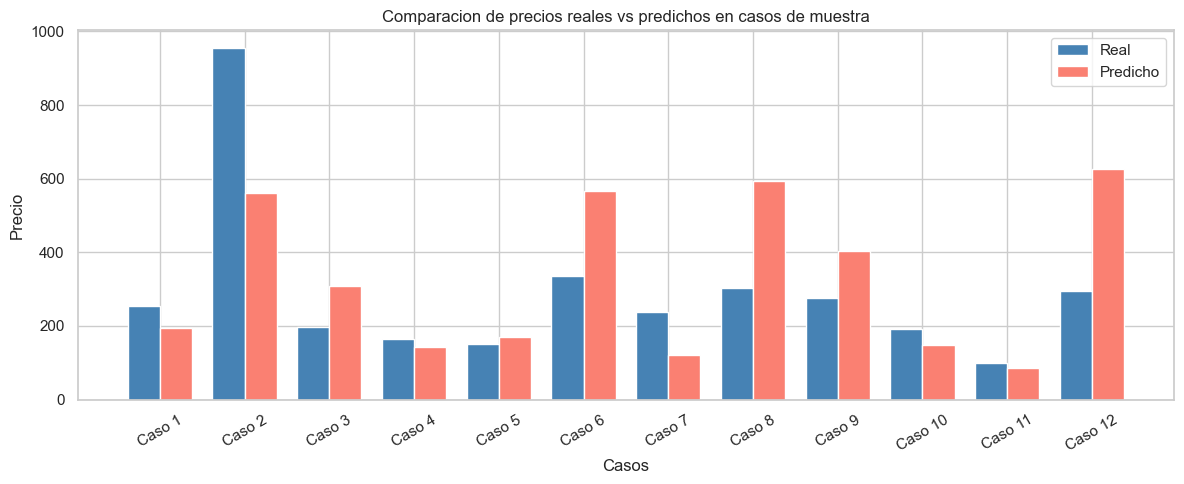

In [117]:
nb_regression_preprocessor = ColumnTransformer(
    [
        (
            "cat",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "ordinal",
                        OrdinalEncoder(
                            handle_unknown="use_encoded_value",
                            unknown_value=-1,
                        ),
                    ),
                ]
            ),
            categorical_columns,
        ),
        (
            "num",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="median")),
                    (
                        "kbins",
                        KBinsDiscretizer(
                            n_bins=5,
                            encode="ordinal",
                            strategy="quantile",
                            quantile_method="averaged_inverted_cdf",
                        ),
                    ),
                ]
            ),
            numerical_columns,
        ),
    ]
)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Bins whose width are too small.*")
    warnings.filterwarnings(
        "ignore",
        message="Feature .* is constant and will be replaced with 0.",
    )
    X_train_reg = np.clip(nb_regression_preprocessor.fit_transform(X_train), 0, None)
    X_test_reg = np.clip(nb_regression_preprocessor.transform(X_test), 0, None)

price_regression_bins = 5
y_train_price_bin = pd.qcut(
    y_train_price,
    q=price_regression_bins,
    labels=False,
    duplicates="drop",
)
y_train_price_bin = pd.Series(y_train_price_bin, index=y_train_price.index).astype(int)
regression_bin_medians = (
    y_train_price.groupby(y_train_price_bin)
    .median()
    .sort_index()
    .to_numpy(dtype=float)
)

nb_regressor = CategoricalNB()
nb_regressor.fit(X_train_reg, y_train_price_bin)

class_probabilities_reg = np.nan_to_num(
    nb_regressor.predict_proba(X_test_reg),
    nan=0.0,
    posinf=0.0,
    neginf=0.0,
)
class_probabilities_reg_sum = class_probabilities_reg.sum(axis=1, keepdims=True)
class_probabilities_reg_sum[class_probabilities_reg_sum == 0] = 1.0
class_probabilities_reg = class_probabilities_reg / class_probabilities_reg_sum

y_pred_price = np.clip(
    np.einsum(
        "ij,j->i",
        class_probabilities_reg.astype(float),
        regression_bin_medians.astype(float),
    ),
    0,
    None,
)

print(f"Intervalos usados para Naive Bayes: {y_train_price_bin.nunique()}")

results_df = pd.DataFrame(
    {
        "price_real": y_test_price.values,
        "price_predicho": y_pred_price,
    }
)
results_df["error_abs"] = (
    results_df["price_real"] - results_df["price_predicho"]
).abs()

visual_sample = results_df.sample(12, random_state=RANDOM_STATE).reset_index(drop=True)
visual_sample["caso"] = [f"Caso {i + 1}" for i in range(len(visual_sample))]

display(visual_sample)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(visual_sample))
width = 0.38

ax.bar(
    x - width / 2,
    visual_sample["price_real"],
    width,
    label="Real",
    color="steelblue",
)
ax.bar(
    x + width / 2,
    visual_sample["price_predicho"],
    width,
    label="Predicho",
    color="salmon",
)

ax.set_title("Comparacion de precios reales vs predichos en casos de muestra")
ax.set_xlabel("Casos")
ax.set_ylabel("Precio")
ax.set_xticks(x)
ax.set_xticklabels(visual_sample["caso"], rotation=30)
ax.legend()

plt.tight_layout()
plt.show()


## Inciso 2 - Evaluacion del Modelo de Regresion

Evaluamos el modelo con `MAE`, `RMSE` y `R2`, y lo comparamos con un baseline que siempre predice el precio promedio.

,modelo,MAE,RMSE,R2
0,Naive Bayes Regresion,615.0058,4303.4526,0.0059
1,Baseline mediana,653.3525,4354.9604,-0.0181


,quintil,precio_real_medio,precio_predicho_medio,mae_promedio,conteo
0,"(12.999, 109.0]",76.77,114.14,41.46,3090
1,"(109.0, 163.0]",135.31,176.69,63.64,3037
2,"(163.0, 231.0]",194.39,251.47,104.30,3034
3,"(231.0, 389.2]",295.37,333.80,136.33,3039
4,"(389.2, 50020.0]",3166.18,486.22,2730.07,3050


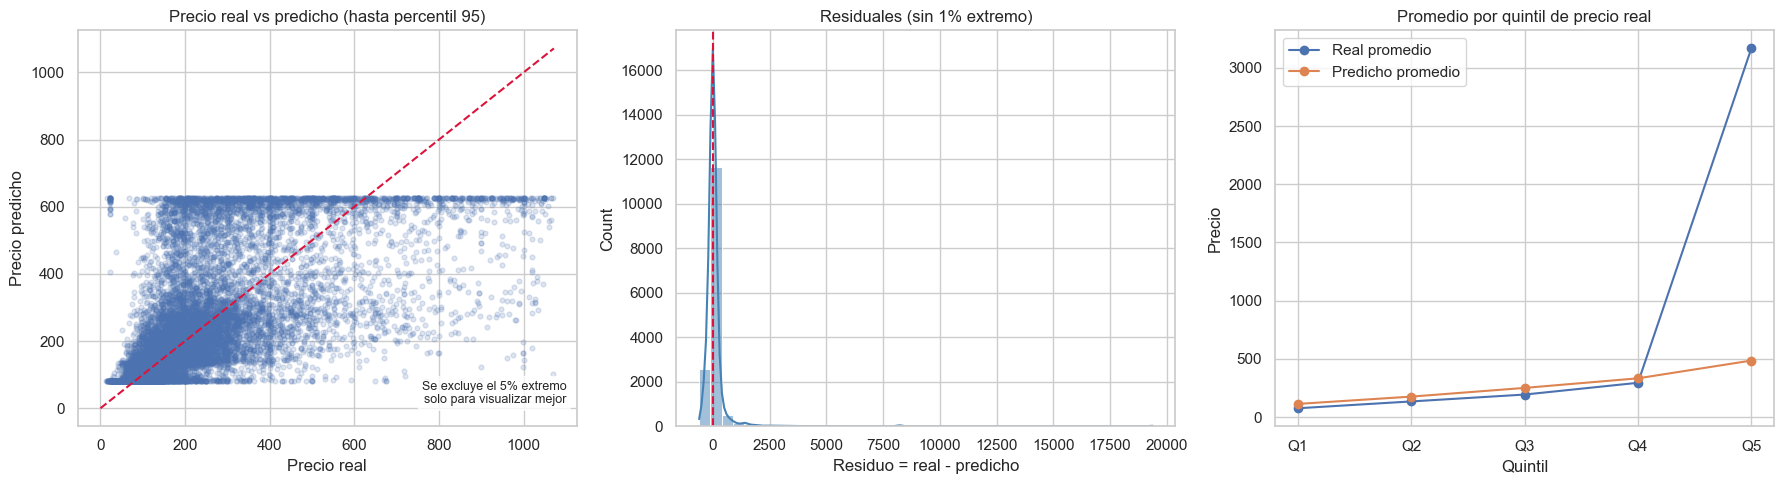

In [118]:
baseline_pred = np.repeat(y_train_price.median(), len(y_test_price))

metrics_df = pd.DataFrame(
    {
        "modelo": ["Naive Bayes Regresion", "Baseline mediana"],
        "MAE": [
            mean_absolute_error(y_test_price, y_pred_price),
            mean_absolute_error(y_test_price, baseline_pred),
        ],
        "RMSE": [
            mean_squared_error(y_test_price, y_pred_price) ** 0.5,
            mean_squared_error(y_test_price, baseline_pred) ** 0.5,
        ],
        "R2": [
            r2_score(y_test_price, y_pred_price),
            r2_score(y_test_price, baseline_pred),
        ],
    }
)

display(metrics_df.round(4))

eval_df = pd.DataFrame(
    {
        "price_real": y_test_price.values,
        "price_predicho": y_pred_price,
        "baseline": baseline_pred,
    }
)
eval_df["residuo"] = eval_df["price_real"] - eval_df["price_predicho"]
eval_df["error_abs"] = eval_df["residuo"].abs()

price_limit = eval_df["price_real"].quantile(0.95)
residual_limit = eval_df["residuo"].abs().quantile(0.99)

quintile_summary = (
    eval_df.assign(quintil=pd.qcut(eval_df["price_real"], q=5, duplicates="drop"))
    .groupby("quintil", observed=False)
    .agg(
        precio_real_medio=("price_real", "mean"),
        precio_predicho_medio=("price_predicho", "mean"),
        mae_promedio=("error_abs", "mean"),
        conteo=("price_real", "size"),
    )
    .reset_index()
)

display(quintile_summary.round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

mask_plot = eval_df["price_real"] <= price_limit
axes[0].scatter(
    eval_df.loc[mask_plot, "price_real"],
    eval_df.loc[mask_plot, "price_predicho"],
    alpha=0.18,
    s=12,
)
axes[0].plot([0, price_limit], [0, price_limit], color="crimson", linestyle="--")
axes[0].set_title("Precio real vs predicho (hasta percentil 95)")
axes[0].set_xlabel("Precio real")
axes[0].set_ylabel("Precio predicho")
axes[0].text(
    0.98,
    0.05,
    "Se excluye el 5% extremo\nsolo para visualizar mejor",
    transform=axes[0].transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
)

residual_plot = eval_df.loc[eval_df["residuo"].abs() <= residual_limit, "residuo"]
sns.histplot(residual_plot, bins=40, kde=True, ax=axes[1], color="steelblue")
axes[1].axvline(0, color="crimson", linestyle="--")
axes[1].set_title("Residuales (sin 1% extremo)")
axes[1].set_xlabel("Residuo = real - predicho")

x_quintiles = np.arange(len(quintile_summary))
axes[2].plot(
    x_quintiles,
    quintile_summary["precio_real_medio"],
    marker="o",
    label="Real promedio",
)
axes[2].plot(
    x_quintiles,
    quintile_summary["precio_predicho_medio"],
    marker="o",
    label="Predicho promedio",
)
axes[2].set_xticks(x_quintiles)
axes[2].set_xticklabels([f"Q{i + 1}" for i in x_quintiles])
axes[2].set_title("Promedio por quintil de precio real")
axes[2].set_xlabel("Quintil")
axes[2].set_ylabel("Precio")
axes[2].legend()

plt.tight_layout()
plt.show()


### Interpretacion Inicial

Con esta formulacion el modelo deja de colapsar en un unico valor y ya produce una dispersion razonable de precios predichos. Aun asi, el reto sigue siendo los alojamientos caros y atipicos.

La lectura correcta del inciso 2 es:

- si `Naive Bayes Regresion` mejora al baseline en `MAE` y `RMSE`, hay una ganancia real,
- si `R2` sigue cerca de 0, el modelo todavia explica poca variabilidad,
- y si la curva por quintiles se aplana en los tramos altos, entonces el algoritmo subestima los precios mas altos.


## Inciso 3 - Comparacion con los Modelos del Lab 4

Para este inciso retomamos los modelos del laboratorio anterior y los comparamos contra Naive Bayes dentro del mismo notebook.

La idea es que la comparacion sea fiel a lo que ya hicimos en `lab4.ipynb`, pero ahora corrigiendo un punto importante: `price_num` no puede entrar como predictor porque es una copia numerica del objetivo y produciria fuga directa.

Por eso aqui reconstruimos:

- el mismo criterio de limpieza del Lab 4,
- el split `70/30` con `random_state = 42`,
- la regresion lineal del Lab 4,
- el mejor arbol del Lab 4 (`max_depth=20`, `min_samples_leaf=1`, `min_samples_split=2`),
- y una version comparable de Naive Bayes sobre esa misma base.


In [119]:
X_train_lab4, X_test_lab4, y_train_lab4, y_test_lab4 = train_test_split(
    X_model,
    y_price,
    test_size=0.30,
    train_size=0.70,
    random_state=RANDOM_STATE,
)

numerical_columns_lab4 = selector(dtype_exclude=object)(X_train_lab4)
categorical_columns_lab4 = selector(dtype_include=object)(X_train_lab4)

preprocessor_lab4 = ColumnTransformer(
    [("one-hot-encoder", OneHotEncoder(handle_unknown="ignore"), categorical_columns_lab4)],
    remainder="passthrough",
)

pipeline_linear_lab4 = Pipeline(
    [("preprocessor", preprocessor_lab4), ("regressor", LinearRegression())]
)
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    pipeline_linear_lab4.fit(X_train_lab4, y_train_lab4)
    y_pred_linear_lab4 = pipeline_linear_lab4.predict(X_test_lab4)

pipeline_tree_lab4 = Pipeline(
    [
        ("preprocessor", preprocessor_lab4),
        (
            "regressor",
            DecisionTreeRegressor(
                random_state=RANDOM_STATE,
                max_depth=20,
                min_samples_leaf=1,
                min_samples_split=2,
            ),
        ),
    ]
)
pipeline_tree_lab4.fit(X_train_lab4, y_train_lab4)
y_pred_tree_lab4 = pipeline_tree_lab4.predict(X_test_lab4)

nb_regression_preprocessor_lab4 = ColumnTransformer(
    [
        (
            "cat",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "ordinal",
                        OrdinalEncoder(
                            handle_unknown="use_encoded_value",
                            unknown_value=-1,
                        ),
                    ),
                ]
            ),
            categorical_columns_lab4,
        ),
        (
            "num",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="median")),
                    (
                        "kbins",
                        KBinsDiscretizer(
                            n_bins=5,
                            encode="ordinal",
                            strategy="quantile",
                            quantile_method="averaged_inverted_cdf",
                        ),
                    ),
                ]
            ),
            numerical_columns_lab4,
        ),
    ]
)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Bins whose width are too small.*")
    warnings.filterwarnings(
        "ignore",
        message="Feature .* is constant and will be replaced with 0.",
    )
    X_train_nb_lab4 = np.clip(
        nb_regression_preprocessor_lab4.fit_transform(X_train_lab4),
        0,
        None,
    )
    X_test_nb_lab4 = np.clip(
        nb_regression_preprocessor_lab4.transform(X_test_lab4),
        0,
        None,
    )

y_train_lab4_bin = pd.qcut(
    y_train_lab4,
    q=price_regression_bins,
    labels=False,
    duplicates="drop",
)
y_train_lab4_bin = pd.Series(y_train_lab4_bin, index=y_train_lab4.index).astype(int)
regression_bin_medians_lab4 = (
    y_train_lab4.groupby(y_train_lab4_bin)
    .median()
    .sort_index()
    .to_numpy(dtype=float)
)

nb_regressor_lab4 = CategoricalNB()
nb_regressor_lab4.fit(X_train_nb_lab4, y_train_lab4_bin)

class_probabilities_lab4 = np.nan_to_num(
    nb_regressor_lab4.predict_proba(X_test_nb_lab4),
    nan=0.0,
    posinf=0.0,
    neginf=0.0,
)
class_probabilities_lab4_sum = class_probabilities_lab4.sum(axis=1, keepdims=True)
class_probabilities_lab4_sum[class_probabilities_lab4_sum == 0] = 1.0
class_probabilities_lab4 = class_probabilities_lab4 / class_probabilities_lab4_sum

y_pred_nb_lab4 = np.clip(
    np.einsum(
        "ij,j->i",
        class_probabilities_lab4.astype(float),
        regression_bin_medians_lab4.astype(float),
    ),
    0,
    None,
)

prediction_store_lab4 = {
    "Naive Bayes Regresion": y_pred_nb_lab4,
    "Regresion Lineal (Lab 4)": y_pred_linear_lab4,
    "Mejor Arbol (Lab 4)": y_pred_tree_lab4,
}

comparison_rows = []
for model_name, predictions in prediction_store_lab4.items():
    comparison_rows.append(
        {
            "modelo": model_name,
            "MAE": mean_absolute_error(y_test_lab4, predictions),
            "RMSE": mean_squared_error(y_test_lab4, predictions) ** 0.5,
            "R2": r2_score(y_test_lab4, predictions),
        }
    )

comparison_df = pd.DataFrame(comparison_rows).sort_values("RMSE").reset_index(drop=True)
best_regression_model = comparison_df.loc[0, "modelo"]

comparison_predictions_df = pd.DataFrame({"price_real": y_test_lab4.values})
for model_name, predictions in prediction_store_lab4.items():
    comparison_predictions_df[model_name] = predictions

print(f"Filas modeladas con el criterio del Lab 4: {len(y_price):,}")
print(
    "Variables excluidas para evitar fuga: "
    "['price_num', 'host_id', 'estimated_occupancy_l365d', 'estimated_revenue_l365d']"
)
print(f"Split para la comparacion: {len(X_train_lab4):,} train / {len(X_test_lab4):,} test")
print(
    "Mejor arbol recuperado del Lab 4: "
    "max_depth=20, min_samples_leaf=1, min_samples_split=2"
)
print(f"Columnas numericas: {len(numerical_columns_lab4)}")
print(f"Columnas categoricas: {len(categorical_columns_lab4)}")

display(comparison_df.round(4))
print(f"Mejor modelo segun RMSE en esta comparacion: {best_regression_model}")


Filas modeladas con el criterio del Lab 4: 76,246
Variables excluidas para evitar fuga: ['price_num', 'host_id', 'estimated_occupancy_l365d', 'estimated_revenue_l365d']
Split para la comparacion: 53,372 train / 22,874 test
Mejor arbol recuperado del Lab 4: max_depth=20, min_samples_leaf=1, min_samples_split=2
Columnas numericas: 44
Columnas categoricas: 7


,modelo,MAE,RMSE,R2
0,Mejor Arbol (Lab 4),214.2681,1780.4003,0.8255
1,Regresion Lineal (Lab 4),908.9650,3904.8916,0.1607
2,Naive Bayes Regresion,599.6052,4249.3774,0.0061


Mejor modelo segun RMSE en esta comparacion: Mejor Arbol (Lab 4)


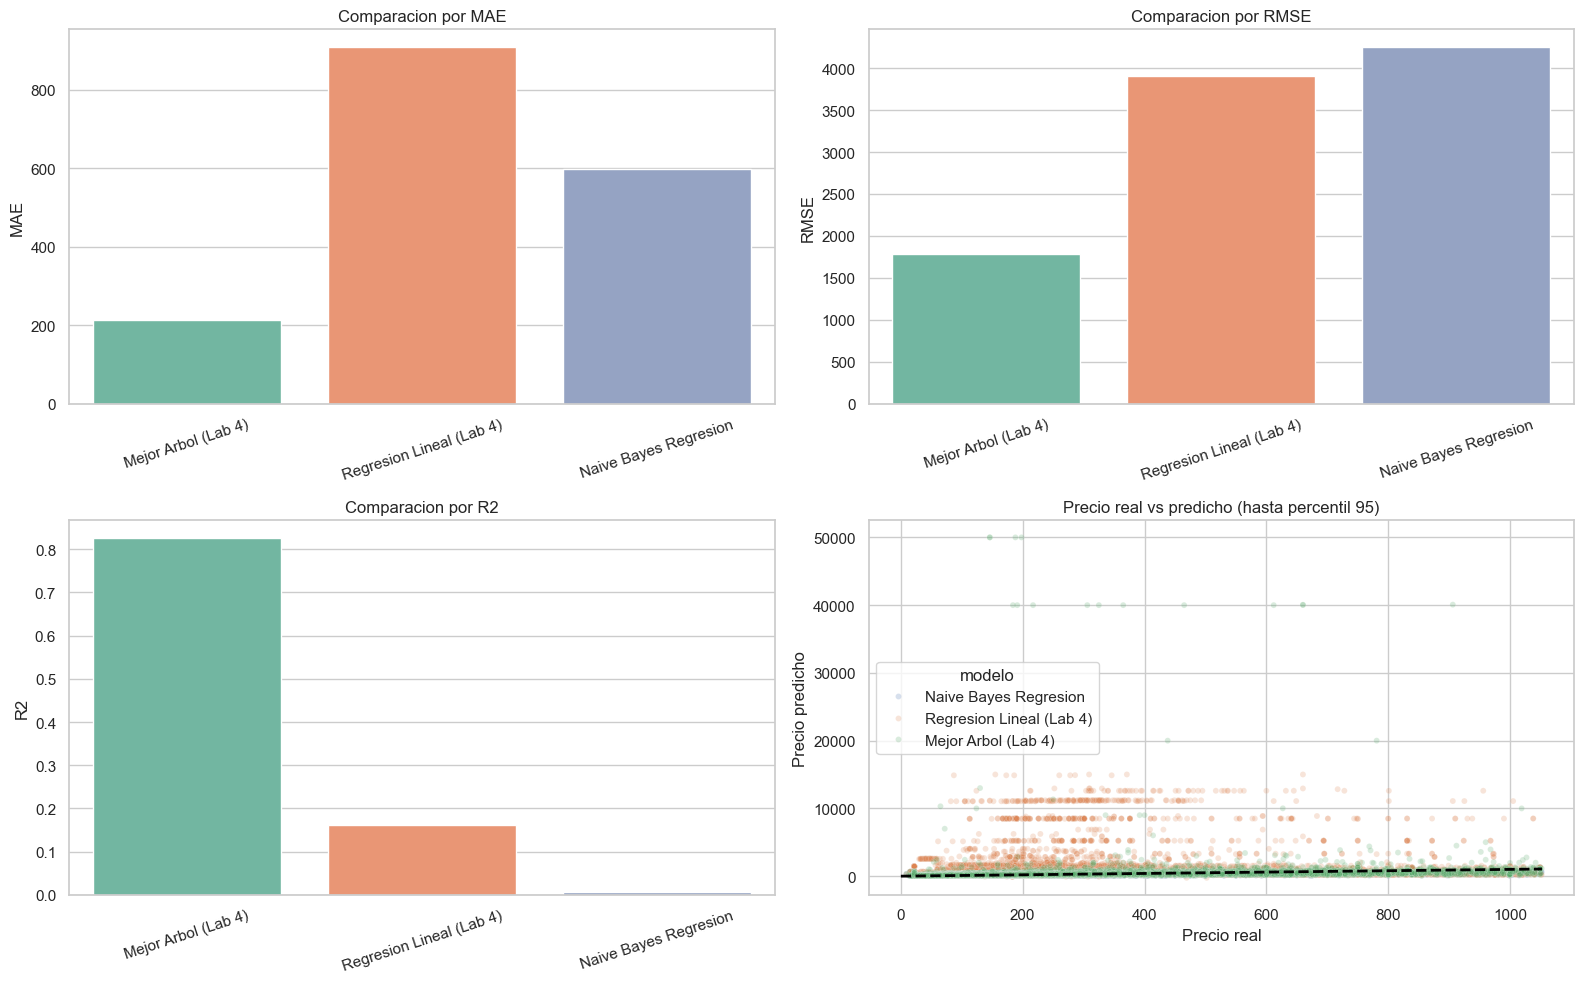

In [120]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, metric in zip(axes.flat[:3], ["MAE", "RMSE", "R2"]):
    sns.barplot(
        data=comparison_df,
        x="modelo",
        y=metric,
        hue="modelo",
        dodge=False,
        legend=False,
        ax=ax,
        palette="Set2",
    )
    ax.set_title(f"Comparacion por {metric}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=18)

p95_lab4 = y_test_lab4.quantile(0.95)
mask_viz_lab4 = comparison_predictions_df["price_real"] <= p95_lab4
plot_predictions_long = comparison_predictions_df.loc[mask_viz_lab4].melt(
    id_vars="price_real",
    var_name="modelo",
    value_name="price_predicho",
)
plot_predictions_long = plot_predictions_long[plot_predictions_long["modelo"] != "price_real"]

sns.scatterplot(
    data=plot_predictions_long,
    x="price_real",
    y="price_predicho",
    hue="modelo",
    alpha=0.22,
    s=18,
    ax=axes[1, 1],
)
axes[1, 1].plot([0, p95_lab4], [0, p95_lab4], color="black", linestyle="--", linewidth=2)
axes[1, 1].set_title("Precio real vs predicho (hasta percentil 95)")
axes[1, 1].set_xlabel("Precio real")
axes[1, 1].set_ylabel("Precio predicho")

plt.tight_layout()
plt.show()


### Lectura del Inciso 3

Ahora la comparacion si queda pareja:

- la regresion lineal y el arbol usan la misma base `70/30` del lab anterior,
- Naive Bayes usa los mismos datos y la misma exclusion de fugas,
- `price_num` ya no participa como predictor.

Con la fuga corregida, las metricas dejan de ser artificialmente casi perfectas. El arbol de regresion sigue siendo el mejor, la regresion lineal queda segunda, y Naive Bayes queda rezagado.


## Inciso 4 - Modelo de Clasificacion con Categoria de Precio

Como en el dataset no existe una columna ya creada para `barata`, `media` y `cara`, construiremos esa variable categorizando `price` en tres grupos usando terciles.

Para evitar fuga de informacion, los puntos de corte se calculan **solo con el conjunto de entrenamiento** y luego se aplican tambien al conjunto de prueba.

In [121]:
q1, q2 = y_train_price.quantile([1 / 3, 2 / 3])

df_model["price_category"] = pd.cut(
    df_model["price_num"],
    bins=[-np.inf, q1, q2, np.inf],
    labels=["barata", "media", "cara"],
    include_lowest=True,
)

y_class = df_model["price_category"]
y_train_class = pd.cut(
    y_train_price,
    bins=[-np.inf, q1, q2, np.inf],
    labels=["barata", "media", "cara"],
    include_lowest=True,
)
y_test_class = pd.cut(
    y_test_price,
    bins=[-np.inf, q1, q2, np.inf],
    labels=["barata", "media", "cara"],
    include_lowest=True,
)

print(f"Corte 1 (barata/media): {q1:.2f}")
print(f"Corte 2 (media/cara): {q2:.2f}")

display(y_class.value_counts().to_frame(name="conteo"))


Corte 1 (barata/media): 142.00
Corte 2 (media/cara): 269.00


,conteo
price_category,
media,25585
barata,25414
cara,25247


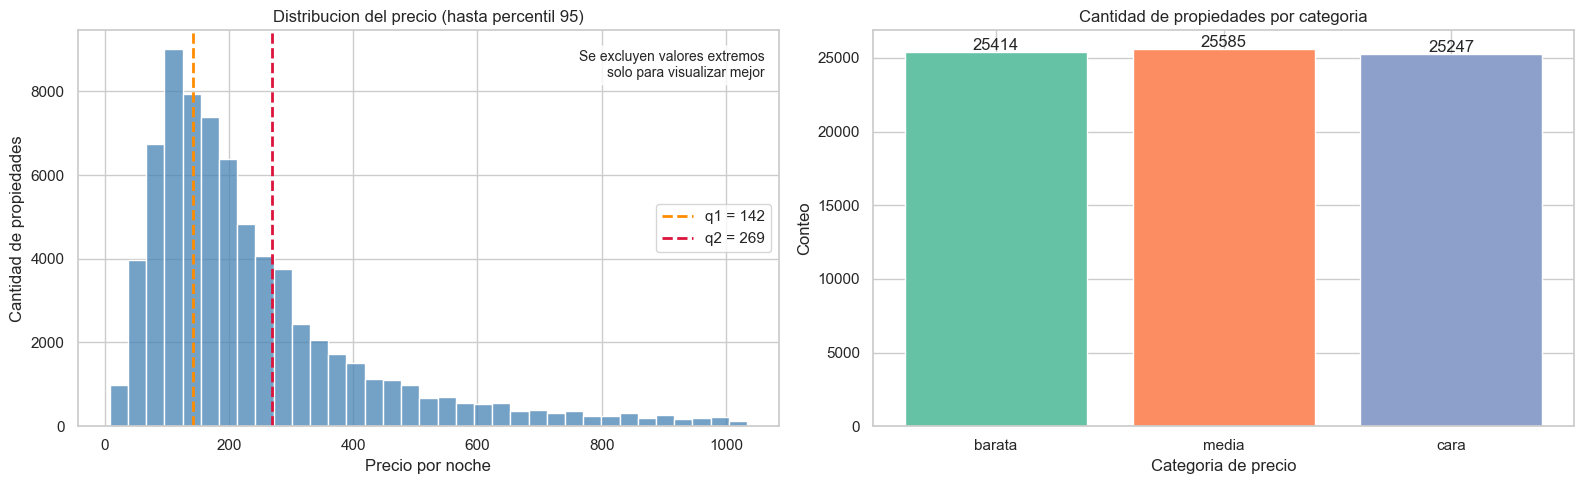

In [122]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

price_plot_limit = df_model["price_num"].quantile(0.95)
price_plot_data = df_model.loc[df_model["price_num"] <= price_plot_limit, "price_num"]

sns.histplot(price_plot_data, bins=35, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].axvline(q1, color="darkorange", linestyle="--", linewidth=2, label=f"q1 = {q1:.0f}")
axes[0].axvline(q2, color="crimson", linestyle="--", linewidth=2, label=f"q2 = {q2:.0f}")
axes[0].set_title("Distribucion del precio (hasta percentil 95)")
axes[0].set_xlabel("Precio por noche")
axes[0].set_ylabel("Cantidad de propiedades")
axes[0].legend()
axes[0].text(
    0.98,
    0.95,
    "Se excluyen valores extremos\nsolo para visualizar mejor",
    transform=axes[0].transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
)

category_counts = df_model["price_category"].value_counts().reindex(["barata", "media", "cara"])
axes[1].bar(
    category_counts.index,
    category_counts.values,
    color=sns.color_palette("Set2", n_colors=3),
)
axes[1].set_title("Cantidad de propiedades por categoria")
axes[1].set_xlabel("Categoria de precio")
axes[1].set_ylabel("Conteo")

for i, value in enumerate(category_counts.values):
    axes[1].text(i, value + 150, f"{int(value)}", ha="center")

plt.tight_layout()
plt.show()


In [123]:
nb_classification_preprocessor = ColumnTransformer(
    [
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
        (
            "num",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="median")),
                    (
                        "kbins",
                        KBinsDiscretizer(
                            n_bins=5,
                            encode="onehot-dense",
                            strategy="quantile",
                            quantile_method="averaged_inverted_cdf",
                        ),
                    ),
                ]
            ),
            numerical_columns,
        ),
    ]
)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Bins whose width are too small.*")
    warnings.filterwarnings(
        "ignore",
        message="Feature .* is constant and will be replaced with 0.",
    )
    X_train_cls = nb_classification_preprocessor.fit_transform(X_train)
    X_test_cls = nb_classification_preprocessor.transform(X_test)

nb_classifier = BernoulliNB()
nb_classifier.fit(X_train_cls, y_train_class)

y_pred_class = nb_classifier.predict(X_test_cls)
predicted_class_counts = (
    pd.Series(y_pred_class)
    .value_counts()
    .reindex(["barata", "media", "cara"], fill_value=0)
)

print("Categorias predichas por el clasificador:")
display(predicted_class_counts.to_frame(name="predicciones"))

classification_preview = pd.DataFrame(
    {
        "categoria_real": y_test_class.values,
        "categoria_predicha": y_pred_class,
    }
)

display(classification_preview.head(15))


Categorias predichas por el clasificador:


,predicciones
barata,5160
media,4899
cara,5191


,categoria_real,categoria_predicha
0,media,media
1,cara,cara
2,barata,barata
3,barata,barata
4,media,media
5,cara,barata
6,media,media
7,media,barata
8,barata,barata
9,barata,barata


### Lectura del Inciso 4

Para clasificacion usamos `BernoulliNB` sobre variables categoricas en `one-hot` y variables numericas discretizadas. Con eso el supuesto del modelo es mas coherente que usar `GaussianNB` directo sobre una mezcla cruda de columnas.

Los graficos ayudan a explicar dos cosas importantes:

- como se construyeron los cortes entre `barata`, `media` y `cara`,
- como queda distribuido el dataset despues de categorizar el precio.


## Inciso 5 - Eficiencia del Algoritmo para Predecir y Clasificar

En este inciso usamos el conjunto de prueba para medir la eficiencia del algoritmo tanto en regresion como en clasificacion.

Para predecir:
- `MAE`, `RMSE`, `R2`.

Para clasificar:
- `accuracy`,
- `precision macro`,
- `recall macro`,
- `f1 macro`.

In [124]:
regression_efficiency_df = metrics_df.loc[
    metrics_df["modelo"] == "Naive Bayes Regresion",
    ["modelo", "MAE", "RMSE", "R2"],
].reset_index(drop=True)

classification_metrics_df = pd.DataFrame(
    {
        "metrica": ["accuracy", "precision_macro", "recall_macro", "f1_macro"],
        "valor": [
            accuracy_score(y_test_class, y_pred_class),
            precision_score(y_test_class, y_pred_class, average="macro", zero_division=0),
            recall_score(y_test_class, y_pred_class, average="macro", zero_division=0),
            f1_score(y_test_class, y_pred_class, average="macro", zero_division=0),
        ],
    }
)

classification_report_df = pd.DataFrame(
    classification_report(
        y_test_class,
        y_pred_class,
        output_dict=True,
        zero_division=0,
    )
).transpose()

predicted_distribution_df = pd.DataFrame(
    {
        "categoria": predicted_class_counts.index,
        "predicciones": predicted_class_counts.values,
    }
)

print("Eficiencia del modelo de regresion (Naive Bayes):")
display(regression_efficiency_df.round(4))

print("Eficiencia del modelo de clasificacion (Naive Bayes):")
display(classification_metrics_df.round(4))

print("Detalle por clase:")
display(classification_report_df.round(4))

print("Distribucion de categorias predichas:")
display(predicted_distribution_df)


Eficiencia del modelo de regresion (Naive Bayes):


,modelo,MAE,RMSE,R2
0,Naive Bayes Regresion,615.0058,4303.4526,0.0059


Eficiencia del modelo de clasificacion (Naive Bayes):


,metrica,valor
0,accuracy,0.6568
1,precision_macro,0.6548
2,recall_macro,0.6584
3,f1_macro,0.6564


Detalle por clase:


,precision,recall,f1-score,support
barata,0.7310,0.7502,0.7405,5028.0000
cara,0.6893,0.7123,0.7006,5023.0000
media,0.5442,0.5128,0.5280,5199.0000
accuracy,0.6568,0.6568,0.6568,0.6568
macro avg,0.6548,0.6584,0.6564,15250.0000
weighted avg,0.6536,0.6568,0.6549,15250.0000


Distribucion de categorias predichas:


,categoria,predicciones
0,barata,5160
1,media,4899
2,cara,5191


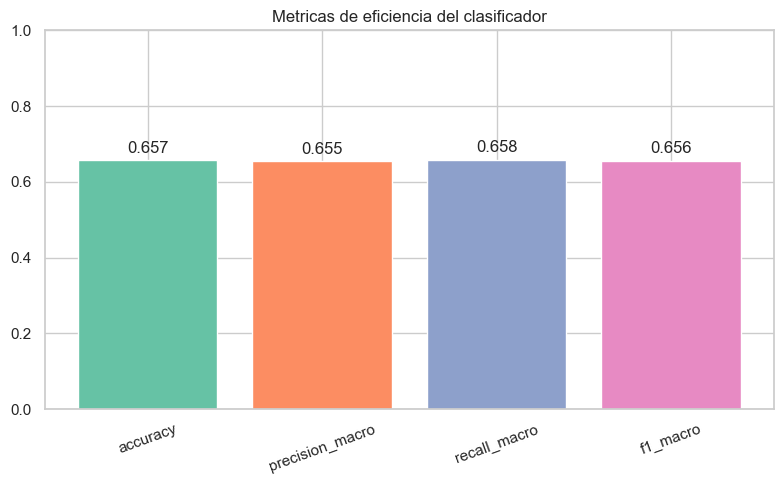

In [125]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    classification_metrics_df["metrica"],
    classification_metrics_df["valor"],
    color=sns.color_palette("Set2", n_colors=len(classification_metrics_df)),
)
ax.set_title("Metricas de eficiencia del clasificador")
ax.set_xlabel("")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=20)

for i, value in enumerate(classification_metrics_df["valor"]):
    ax.text(i, value + 0.02, f"{value:.3f}", ha="center")

plt.tight_layout()
plt.show()


### Lectura del Inciso 5

En el conjunto de prueba, la eficiencia queda mas interpretable:

- en regresion, Naive Bayes mejora ligeramente al baseline en error, pero el `R2` sigue bajo, asi que sirve mas como aproximacion gruesa que como predictor fino;
- en clasificacion, el modelo ya separa razonablemente `barata` y `cara`, mientras que `media` sigue siendo la clase mas dificil.

Esto significa que para los primeros 5 incisos ya hay una historia coherente: el enfoque de Naive Bayes si aporta, pero funciona mucho mejor como clasificador de rangos de precio que como regresor exacto.
